# Exploration and Exploitation in Multi-Armed Bandits

Multi-armed bandits provide a simple setting for studying one of the central problems in reinforcement learning: the **exploration–exploitation trade-off**.

An agent repeatedly chooses among several actions without initially knowing their expected rewards. At each time step, the agent must decide whether to:

- **exploit** an action that currently appears to be the best, or
- **explore** other actions to obtain more information about their potential rewards.

This notebook implements the following action-selection methods from scratch:

1. Greedy action selection
2. $\epsilon$-greedy action selection
3. Upper-Confidence-Bound (UCB) action selection
4. Thompson Sampling

The three methods use the standard **10-armed Gaussian testbed**.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_distribution

## 2. Multi-Armed Bandit Problem

A $k$-armed bandit contains $k$ possible actions:

$$
a\in\{1,2,\ldots,k\}.
$$

At time step $t$, the agent selects an action $A_t$ and receives a reward $R_t$.

Each action has a true action value

$$
q_*(a)=\mathbb{E}[R_t\mid A_t=a],
$$

which represents the expected reward obtained by selecting action $a$.

The true action values are unknown to the agent. Therefore, the agent must estimate them from observed rewards while deciding which actions to select.

## 3. The 10-Armed Gaussian Testbed

For the standard 10-armed testbed,

$$
k=10.
$$

For each bandit problem, the true action value of every action is independently sampled from

$$
q_*(a)\sim\mathcal{N}(0,1).
$$

When action $A_t$ is selected, the reward is generated from

$$
R_t\sim\mathcal{N}(q_*(A_t),1).
$$

Thus, each action has its own reward distribution centered at $q_*(a)$. The optimal action is

$$
a_*=\arg\max_a q_*(a).
$$

The simulated environment knows the true values, but the learning algorithm does not.

In [5]:
# Create one reproducible 10-armed Gaussian bandit.
rng = np.random.default_rng(42)
k = 10

q_true = rng.normal(loc=0.0, scale=1.0, size=k)
optimal_action = np.argmax(q_true)

print("True action values")
print("-" * 40)
for a, value in enumerate(q_true, start=1):
    print(f"Action {a:2d}: q*(a) = {value:.3f}")

print("-" * 40)
print(f"Optimal action       : {optimal_action + 1}")
print(f"Optimal action value : {q_true[optimal_action]:.3f}")

True action values
----------------------------------------
Action  1: q*(a) = 0.305
Action  2: q*(a) = -1.040
Action  3: q*(a) = 0.750
Action  4: q*(a) = 0.941
Action  5: q*(a) = -1.951
Action  6: q*(a) = -1.302
Action  7: q*(a) = 0.128
Action  8: q*(a) = -0.316
Action  9: q*(a) = -0.017
Action 10: q*(a) = -0.853
----------------------------------------
Optimal action       : 4
Optimal action value : 0.941


## 4. Figure 2.1: Reward Distributions of the 10 Actions

The true action value $q_*(a)$ is the mean reward of action $a$, not a deterministic reward. For each action,

$$
R\mid A=a\sim\mathcal{N}(q_*(a),1).
$$

Repeated selections of the same action can therefore produce different rewards around $q_*(a)$.

The following violin plot visualizes one randomly generated 10-armed testbed. Because the testbed itself is stochastic, an independently generated realization is not expected to match the printed book figure pixel-for-pixel, but it follows the same distributional definition.

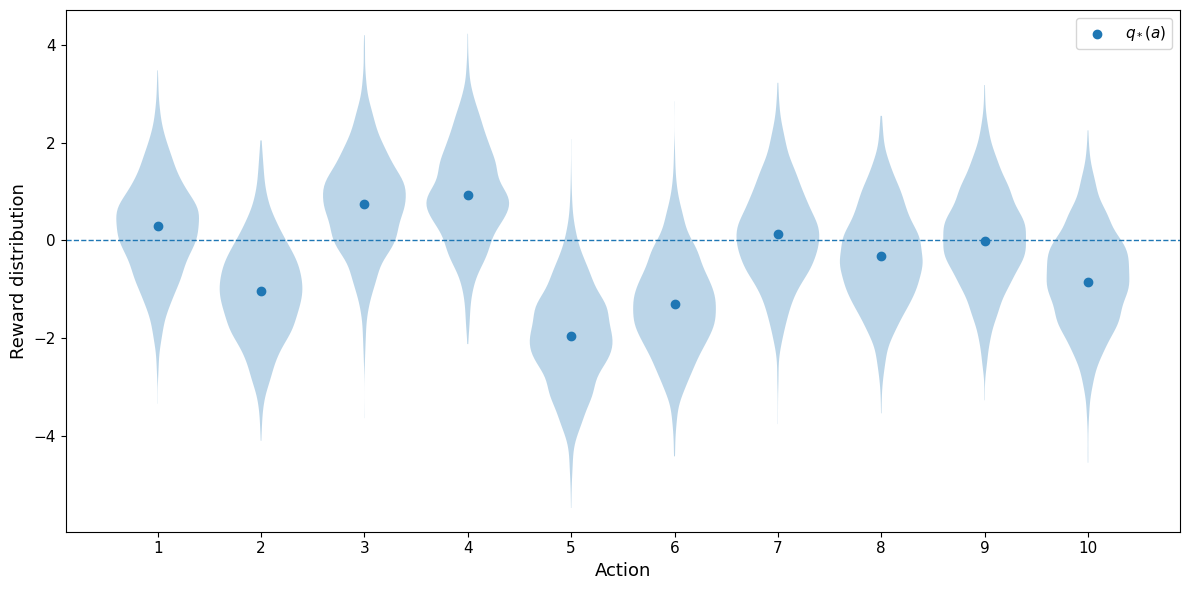

In [6]:
# Generate reward samples only for visualizing the 10 distributions.
n_visual_samples = 2000
reward_samples = [
    rng.normal(loc=q_true[a], scale=1.0, size=n_visual_samples)
    for a in range(k)
]

plt.figure(figsize=(12, 6))
plt.violinplot(
    reward_samples,
    positions=np.arange(1, k + 1),
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False
)
plt.scatter(np.arange(1, k + 1), q_true, zorder=3, label=r"$q_*(a)$")
plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Action", fontsize=13)
plt.ylabel("Reward distribution", fontsize=13)
plt.xticks(np.arange(1, k + 1))
plt.tick_params(axis="both", labelsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 5. Action-Value Estimation

Because $q_*(a)$ is unknown, the agent maintains an estimate

$$
Q_t(a)\approx q_*(a).
$$

Using sample-average estimation,

$$
Q_t(a)=
\frac{\sum_{i=1}^{t-1}R_i\mathbf{1}_{A_i=a}}
{\sum_{i=1}^{t-1}\mathbf{1}_{A_i=a}}.
$$

Equivalently,

$$
Q_t(a)=
\frac{\text{sum of rewards received from action }a}
{\text{number of times action }a\text{ was selected}}.
$$

Instead of storing every previous reward, the estimate can be updated incrementally after the selected action has been counted:

$$
Q_{t+1}(A_t)
=
Q_t(A_t)
+
\frac{1}{N_t(A_t)}
\left[R_t-Q_t(A_t)\right].
$$

The term $R_t-Q_t(A_t)$ is the estimation error.

## 6. Greedy Action Selection

The greedy method always selects an action with the largest current estimate:

$$
A_t=\arg\max_a Q_t(a).
$$

This is pure exploitation. Initially,

$$
Q_1(a)=0
$$

for all actions, and ties are broken randomly.

Because rewards are stochastic, an early high reward from a suboptimal action can make it appear better than it really is. Pure greedy selection has no deliberate mechanism for exploring actions that currently appear inferior.

## 7. $\epsilon$-Greedy Action Selection

The $\epsilon$-greedy method introduces explicit exploration:

$$
A_t=
\begin{cases}
\text{random action}, & \text{with probability }\epsilon,\\
\arg\max_a Q_t(a), & \text{with probability }1-\epsilon.
\end{cases}
$$

Therefore:

- $\epsilon=0$ is pure greedy action selection,
- $\epsilon=0.01$ explores approximately 1% of the time,
- $\epsilon=0.1$ explores approximately 10% of the time.

During exploration, all $k$ actions are equally likely. Once the optimal action has been correctly identified, its probability of selection is

$$
P(A_t=a_*)=(1-\epsilon)+\frac{\epsilon}{k}.
$$

For $k=10$ and $\epsilon=0.1$,

$$
P(A_t=a_*)=0.9+\frac{0.1}{10}=0.91.
$$

In [7]:
def epsilon_greedy(Q, epsilon, rng):
    # Explore with probability epsilon.
    if rng.random() < epsilon:
        return rng.integers(len(Q))

    # Otherwise exploit. Break ties randomly.
    max_value = np.max(Q)
    greedy_actions = np.flatnonzero(Q == max_value)
    return rng.choice(greedy_actions)


def run_bandit(q_true, epsilon, steps, rng):
    k = len(q_true)
    Q = np.zeros(k)
    N = np.zeros(k, dtype=int)

    rewards = np.zeros(steps)
    optimal_selected = np.zeros(steps)
    optimal_action = np.argmax(q_true)

    for t in range(steps):
        action = epsilon_greedy(Q, epsilon, rng)
        reward = rng.normal(loc=q_true[action], scale=1.0)

        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]

        rewards[t] = reward
        optimal_selected[t] = int(action == optimal_action)

    return rewards, optimal_selected

## 8. Greedy vs. $\epsilon$-Greedy: 2000-Run Experiment

Following the standard 10-armed testbed experiment, the methods

$$
\epsilon\in\{0,\;0.01,\;0.1\}
$$

are evaluated over

$$
2000
$$

independent bandit problems, each run for

$$
1000
$$

time steps.

The same 2000 underlying bandit problems are used for every method so that the comparison is based on identical true action values.

Two performance measures are recorded:

1. **Average reward** at each time step.
2. **Percentage of optimal-action selections** at each time step.

In [8]:
k = 10
n_runs = 2000
n_steps = 1000
epsilons = [0.0, 0.01, 0.1]

# Generate one common collection of bandit problems for all methods.
problem_rng = np.random.default_rng(12345)
bandit_problems = problem_rng.normal(loc=0.0, scale=1.0, size=(n_runs, k))

average_rewards = {}
optimal_action_percentages = {}

for method_index, epsilon in enumerate(epsilons):
    all_rewards = np.zeros((n_runs, n_steps))
    all_optimal = np.zeros((n_runs, n_steps))
    method_rng = np.random.default_rng(1000 + method_index)

    for run in range(n_runs):
        rewards, optimal = run_bandit(
            bandit_problems[run], epsilon, n_steps, method_rng
        )
        all_rewards[run] = rewards
        all_optimal[run] = optimal

    average_rewards[epsilon] = all_rewards.mean(axis=0)
    optimal_action_percentages[epsilon] = all_optimal.mean(axis=0) * 100

print("Greedy and epsilon-greedy experiment completed.")
print(f"Independent bandit problems: {n_runs}")
print(f"Steps per problem          : {n_steps}")

Greedy and epsilon-greedy experiment completed.
Independent bandit problems: 2000
Steps per problem          : 1000


## 9. Figure 2.2: Average Reward

The first performance measure is the reward obtained at each time step, averaged over all independent runs. Higher average reward indicates that the method is more frequently selecting actions with high true action values.

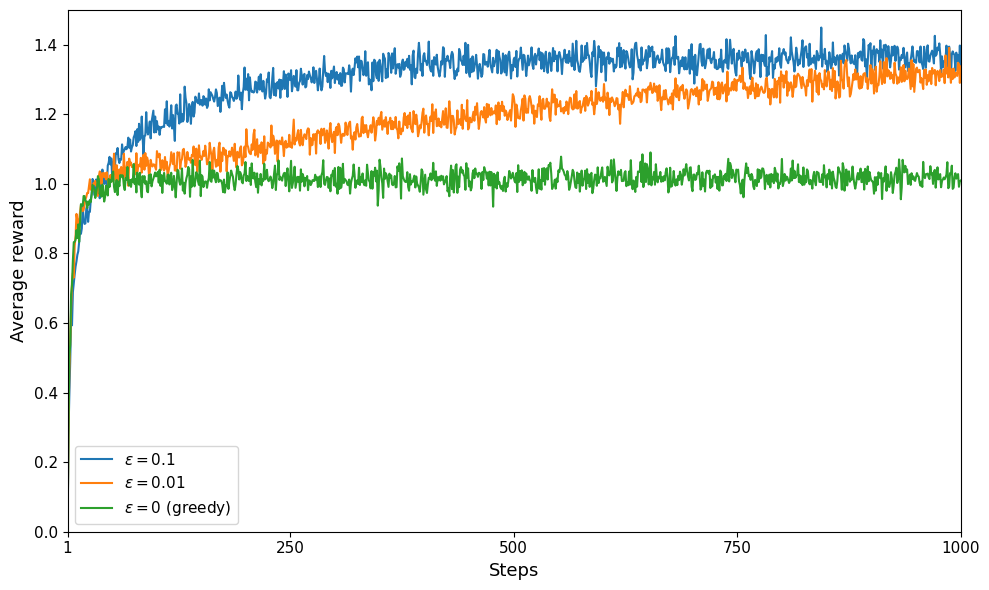

In [9]:
steps = np.arange(1, n_steps + 1)

plt.figure(figsize=(10, 6))
plt.plot(steps, average_rewards[0.1], label=r"$\epsilon=0.1$")
plt.plot(steps, average_rewards[0.01], label=r"$\epsilon=0.01$")
plt.plot(steps, average_rewards[0.0], label=r"$\epsilon=0$ (greedy)")

plt.xlabel("Steps", fontsize=13)
plt.ylabel("Average reward", fontsize=13)
plt.xlim(1, 1000)
plt.ylim(0, 1.5)
plt.xticks([1, 250, 500, 750, 1000])
plt.tick_params(axis="both", labelsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 10. Figure 2.2: Percentage of Optimal-Action Selections

For each bandit problem,

$$
a_*=\arg\max_a q_*(a).
$$

At each step we record

$$
I_t=
\begin{cases}
1, & A_t=a_*,\\
0, & A_t\neq a_*.
\end{cases}
$$

The indicator is averaged across the 2000 runs and expressed as a percentage.

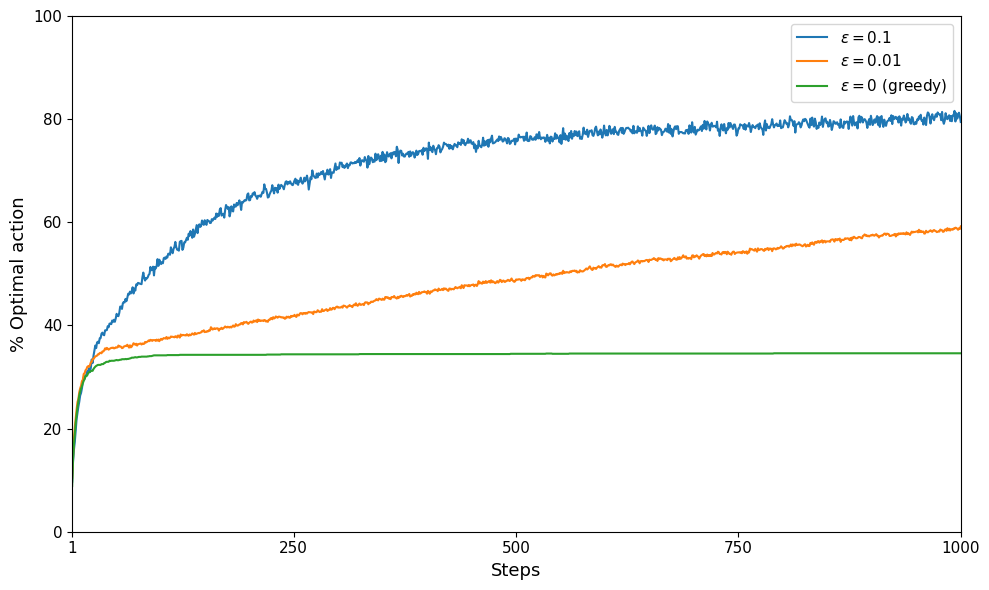

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(steps, optimal_action_percentages[0.1], label=r"$\epsilon=0.1$")
plt.plot(steps, optimal_action_percentages[0.01], label=r"$\epsilon=0.01$")
plt.plot(steps, optimal_action_percentages[0.0], label=r"$\epsilon=0$ (greedy)")

plt.xlabel("Steps", fontsize=13)
plt.ylabel("% Optimal action", fontsize=13)
plt.xlim(1, 1000)
plt.ylim(0, 100)
plt.xticks([1, 250, 500, 750, 1000])
plt.yticks([0, 20, 40, 60, 80, 100])
plt.tick_params(axis="both", labelsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Interpretation

Pure greedy action selection can become committed to a suboptimal action because of noisy early rewards.

The $\epsilon$-greedy methods continue exploring and can therefore correct inaccurate early estimates. With $\epsilon=0.1$, exploration occurs more frequently and the optimal action can be discovered relatively quickly. With $\epsilon=0.01$, exploration is less frequent, so learning can be slower, but fewer selections are spent on random exploration after useful estimates have been obtained.

This illustrates the central trade-off:

$$
\text{exploration}\longleftrightarrow\text{exploitation}.
$$

# Upper-Confidence-Bound Action Selection

Random exploration in $\epsilon$-greedy does not distinguish between actions that have already been explored extensively and actions whose values remain uncertain.

Upper-Confidence-Bound (UCB) action selection uses uncertainty directly:

$$
A_t=
\arg\max_a
\left[
Q_t(a)+c\sqrt{\frac{\ln t}{N_t(a)}}
\right].
$$

Here:

- $Q_t(a)$ is the estimated action value,
- $N_t(a)$ is the number of times action $a$ has been selected,
- $t$ is the current time step,
- $c>0$ controls the amount of exploration.

The score consists of

$$
\text{UCB}_t(a)
=
\underbrace{Q_t(a)}_{\text{exploitation}}
+
\underbrace{c\sqrt{\frac{\ln t}{N_t(a)}}}_{\text{exploration bonus}}.
$$

An action with a high estimated reward is attractive because of $Q_t(a)$. An action selected only a few times receives a larger uncertainty bonus.

For an untried action, $N_t(a)=0$ and the expression is undefined. In the implementation below, untried actions are therefore given priority. We use

$$
c=2.
$$

In [11]:
def select_ucb_action(Q, N, t, rng, c=2.0):
    # Give priority to actions that have never been selected.
    untried_actions = np.flatnonzero(N == 0)

    if len(untried_actions) > 0:
        return rng.choice(untried_actions), None, None

    exploration_bonus = c * np.sqrt(np.log(t) / N)
    ucb_values = Q + exploration_bonus

    max_value = np.max(ucb_values)
    best_actions = np.flatnonzero(ucb_values == max_value)
    action = rng.choice(best_actions)

    return action, exploration_bonus, ucb_values

## 11. Step-by-Step UCB Demonstration

The following experiment applies UCB to the previously generated single 10-armed Gaussian bandit for **60 steps**.

For each step, the output reports the selected action, reward, action count, estimated value, exploration bonus, UCB score, updated estimate, and whether the selected action is truly optimal.

The true $q_*(a)$ values are shown only for evaluation; the UCB algorithm does not use them.

In [12]:
c = 2.0
demo_steps = 60
demo_rng = np.random.default_rng(2026)

Q_ucb = np.zeros(k)
N_ucb = np.zeros(k, dtype=int)
optimal_action = np.argmax(q_true)

print("True action values:")
print(np.round(q_true, 3))
print(f"\nTrue optimal action: {optimal_action + 1}")
print(f"True optimal value : {q_true[optimal_action]:.3f}\n")

for t in range(1, demo_steps + 1):
    action, bonus, ucb_values = select_ucb_action(
        Q_ucb, N_ucb, t, demo_rng, c
    )

    reward = demo_rng.normal(loc=q_true[action], scale=1.0)

    old_Q = Q_ucb[action]
    old_N = N_ucb[action]

    N_ucb[action] += 1
    Q_ucb[action] += (reward - Q_ucb[action]) / N_ucb[action]

    print(f"Step {t:2d}")
    print(f"Selected action   : {action + 1}")
    print(f"Reward            : {reward:.3f}")
    print(f"N before update   : {old_N}")
    print(f"Q before update   : {old_Q:.3f}")

    if bonus is None:
        print("UCB decision      : Untried action given priority")
    else:
        print(f"Exploration bonus : {bonus[action]:.3f}")
        print(f"UCB score         : {ucb_values[action]:.3f}")

    print(f"N after update    : {N_ucb[action]}")
    print(f"Q after update    : {Q_ucb[action]:.3f}")
    print(f"Optimal action?   : {'Yes' if action == optimal_action else 'No'}")
    print("-" * 50)

True action values:
[ 0.305 -1.04   0.75   0.941 -1.951 -1.302  0.128 -0.316 -0.017 -0.853]

True optimal action: 4
True optimal value : 0.941

Step  1
Selected action   : 9
Reward            : 0.224
N before update   : 0
Q before update   : 0.000
UCB decision      : Untried action given priority
N after update    : 1
Q after update    : 0.224
Optimal action?   : No
--------------------------------------------------
Step  2
Selected action   : 2
Reward            : -2.936
N before update   : 0
Q before update   : 0.000
UCB decision      : Untried action given priority
N after update    : 1
Q after update    : -2.936
Optimal action?   : No
--------------------------------------------------
Step  3
Selected action   : 1
Reward            : 0.943
N before update   : 0
Q before update   : 0.000
UCB decision      : Untried action given priority
N after update    : 1
Q after update    : 0.943
Optimal action?   : No
--------------------------------------------------
Step  4
Selected action   

## 12. UCB Estimates After 60 Steps

The following table compares the learned $Q(a)$ estimates with the true action values. The true values are known because this is a simulated environment, but they are not available to the agent.

In [13]:
print(f"{'Action':<8}{'True q*(a)':<15}{'Estimated Q(a)':<18}{'Selections':<12}")
print("-" * 53)

for a in range(k):
    print(
        f"{a + 1:<8}"
        f"{q_true[a]:<15.3f}"
        f"{Q_ucb[a]:<18.3f}"
        f"{N_ucb[a]:<12d}"
    )

Action  True q*(a)     Estimated Q(a)    Selections  
-----------------------------------------------------
1       0.305          0.257             5           
2       -1.040         -2.936            1           
3       0.750          0.942             14          
4       0.941          0.862             12          
5       -1.951         -2.243            1           
6       -1.302         -1.243            2           
7       0.128          0.807             13          
8       -0.316         -0.026            6           
9       -0.017         -0.300            3           
10      -0.853         -1.043            3           


## 13. Full UCB Evaluation

UCB is now evaluated over the same 2000 bandit problems and 1000 steps used for the $\epsilon$-greedy experiment. The same underlying `bandit_problems` are reused for a consistent comparison.

In [14]:
def run_ucb_bandit(q_true, c, steps, rng):
    k = len(q_true)
    Q = np.zeros(k)
    N = np.zeros(k, dtype=int)

    rewards = np.zeros(steps)
    optimal_selected = np.zeros(steps)
    optimal_action = np.argmax(q_true)

    for t in range(1, steps + 1):
        action, _, _ = select_ucb_action(Q, N, t, rng, c)
        reward = rng.normal(loc=q_true[action], scale=1.0)

        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]

        rewards[t - 1] = reward
        optimal_selected[t - 1] = int(action == optimal_action)

    return rewards, optimal_selected


c = 2.0
all_ucb_rewards = np.zeros((n_runs, n_steps))
all_ucb_optimal = np.zeros((n_runs, n_steps))
ucb_rng = np.random.default_rng(3000)

for run in range(n_runs):
    rewards, optimal = run_ucb_bandit(
        bandit_problems[run], c, n_steps, ucb_rng
    )
    all_ucb_rewards[run] = rewards
    all_ucb_optimal[run] = optimal

ucb_average_reward = all_ucb_rewards.mean(axis=0)
ucb_optimal_percentage = all_ucb_optimal.mean(axis=0) * 100

print("UCB evaluation completed.")
print(f"Independent runs                  : {n_runs}")
print(f"Steps per run                     : {n_steps}")
print(f"UCB parameter c                   : {c}")
print(f"Overall mean reward               : {all_ucb_rewards.mean():.3f}")
print(f"Overall optimal-action percentage : {all_ucb_optimal.mean() * 100:.2f}%")

UCB evaluation completed.
Independent runs                  : 2000
Steps per run                     : 1000
UCB parameter c                   : 2.0
Overall mean reward               : 1.387
Overall optimal-action percentage : 75.59%


## 14. Figure 2.4: UCB vs. $\epsilon$-Greedy

The UCB experiment is compared with $\epsilon$-greedy using

$$
c=2
$$

and

$$
\epsilon=0.1.
$$

For $\epsilon$-greedy, exploration is random. UCB instead chooses according to

$$
Q_t(a)+c\sqrt{\frac{\ln t}{N_t(a)}},
$$

so its exploration is influenced by both estimated reward and uncertainty.

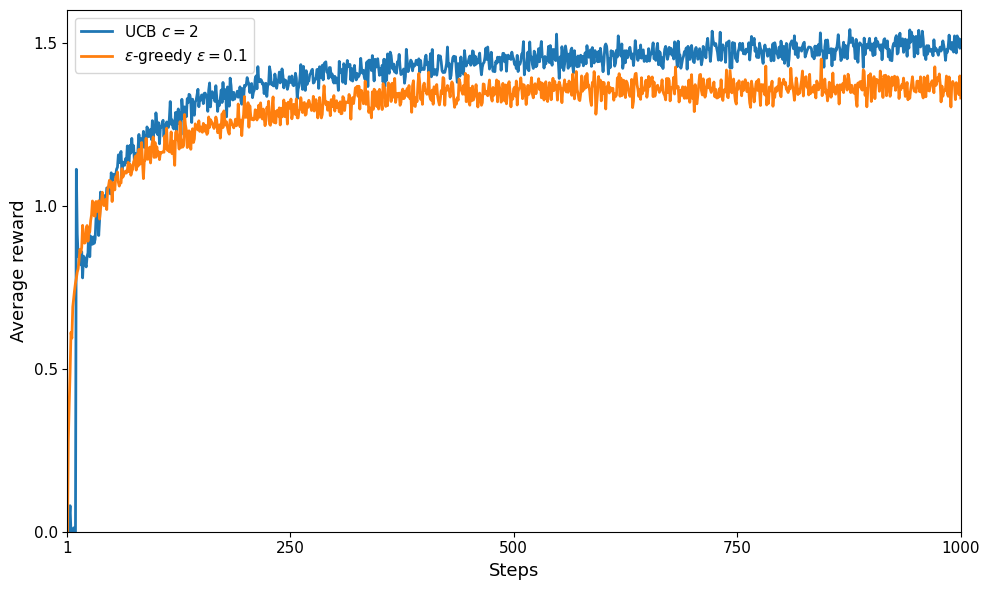

In [15]:
# Figure 2.4-style average-reward comparison.
plt.figure(figsize=(10, 6))

plt.plot(
    steps,
    ucb_average_reward,
    label=r"UCB $c=2$",
    linewidth=2
)
plt.plot(
    steps,
    average_rewards[0.1],
    label=r"$\epsilon$-greedy $\epsilon=0.1$",
    linewidth=2
)

plt.xlabel("Steps", fontsize=13)
plt.ylabel("Average reward", fontsize=13)
plt.xlim(1, 1000)
plt.ylim(0, 1.6)
plt.xticks([1, 250, 500, 750, 1000])
plt.yticks([0, 0.5, 1.0, 1.5])
plt.tick_params(axis="both", labelsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Interpretation of the UCB Comparison

UCB initially gives priority to untried actions. After all actions have been sampled, it balances the estimated value and exploration bonus:

$$
Q_t(a)+c\sqrt{\frac{\ln t}{N_t(a)}}.
$$

As $N_t(a)$ increases, the uncertainty bonus for that action decreases. If an action is neglected while $t$ continues to grow, its bonus can gradually increase. This prevents uncertainty from being ignored permanently.

Unlike $\epsilon$-greedy, UCB does not explore uniformly at random; it directs exploration using uncertainty.

# Thompson Sampling

The Beta-Bernoulli Thompson Sampling algorithm considered here requires a **different bandit reward model** from the Gaussian testbed above.

For greedy, $\epsilon$-greedy, and UCB, rewards were continuous:

$$
R_t\sim\mathcal N(q_*(A_t),1).
$$

For the Thompson Sampling example below, each arm instead has an unknown fixed success probability $p_a$ and produces a binary reward:

$$
R_t\sim\operatorname{Bernoulli}(p_{A_t}),
\qquad
R_t\in\{0,1\}.
$$

This permits a Beta distribution to be used as a conjugate posterior for each unknown Bernoulli success probability. Thompson Sampling itself is not limited to Bernoulli rewards; this section implements the Beta-Bernoulli form.

## 15. The 10-Armed Bernoulli Bandit

Each action $a$ has an unknown fixed success probability

$$
p_a=P(R_t=1\mid A_t=a).
$$

When action $a$ is selected,

$$
R_t\mid A_t=a\sim\operatorname{Bernoulli}(p_a).
$$

Thus,

$$
R_t=
\begin{cases}
1, & \text{with probability }p_a,\\
0, & \text{with probability }1-p_a.
\end{cases}
$$

For Bernoulli rewards,

$$
q_*(a)=\mathbb{E}[R_t\mid A_t=a]=p_a.
$$

Therefore,

$$
a_*=\arg\max_a p_a.
$$

The true probabilities are used only by the simulated environment to generate rewards and evaluate learning.

In [16]:
# Create a reproducible 10-armed Bernoulli bandit.
ts_rng = np.random.default_rng(42)
k = 10

true_probabilities = ts_rng.uniform(0.0, 1.0, size=k)
optimal_action_ts = np.argmax(true_probabilities)

print("True success probabilities")
print("-" * 38)

for a, p in enumerate(true_probabilities, start=1):
    print(f"Action {a:2d}: p = {p:.3f}")

print("-" * 38)
print(f"Optimal action      : {optimal_action_ts + 1}")
print(f"Optimal probability : {true_probabilities[optimal_action_ts]:.3f}")

True success probabilities
--------------------------------------
Action  1: p = 0.774
Action  2: p = 0.439
Action  3: p = 0.859
Action  4: p = 0.697
Action  5: p = 0.094
Action  6: p = 0.976
Action  7: p = 0.761
Action  8: p = 0.786
Action  9: p = 0.128
Action 10: p = 0.450
--------------------------------------
Optimal action      : 6
Optimal probability : 0.976


## 16. Beta Posterior Distribution

For each action, uncertainty about the unknown success probability is represented as

$$
p_a\mid\mathcal D_t
\sim
\operatorname{Beta}(\alpha_a,\beta_a).
$$

The mean of a Beta distribution is

$$
\mathbb{E}[p_a]
=
\frac{\alpha_a}{\alpha_a+\beta_a}.
$$

Following the example used here, all actions begin with

$$
p_a\sim\operatorname{Beta}(2,2),
$$

whose mean is

$$
\frac{2}{2+2}=0.5.
$$

The prior is the same for every action, but the posterior distributions change as successes and failures are observed.

In [17]:
alpha = np.full(k, 2.0)
beta = np.full(k, 2.0)
posterior_means = alpha / (alpha + beta)

print("Initial Thompson Sampling beliefs")
print("-" * 55)
print(f"{'Action':<10}{'Alpha':<10}{'Beta':<10}{'Posterior Mean':<15}")
print("-" * 55)

for a in range(k):
    print(
        f"{a + 1:<10}"
        f"{alpha[a]:<10.0f}"
        f"{beta[a]:<10.0f}"
        f"{posterior_means[a]:<15.3f}"
    )

Initial Thompson Sampling beliefs
-------------------------------------------------------
Action    Alpha     Beta      Posterior Mean 
-------------------------------------------------------
1         2         2         0.500          
2         2         2         0.500          
3         2         2         0.500          
4         2         2         0.500          
5         2         2         0.500          
6         2         2         0.500          
7         2         2         0.500          
8         2         2         0.500          
9         2         2         0.500          
10        2         2         0.500          


## 17. Thompson Sampling Action Selection

At time step $t$, one possible success probability is independently sampled from every posterior:

$$
\tilde p_t(a)
\sim
\operatorname{Beta}(\alpha_a,\beta_a).
$$

The action with the largest sampled value is selected:

$$
A_t=\arg\max_a\tilde p_t(a).
$$

The sampled value $\tilde p_t(a)$ is **not** the same as the posterior mean

$$
\frac{\alpha_a}{\alpha_a+\beta_a}.
$$

A new random value is sampled from each posterior at every step. Uncertain actions can occasionally generate large samples and be explored, while actions whose posteriors support high success probabilities tend to be selected more frequently.

In [18]:
def select_thompson_action(alpha, beta, rng):
    samples = rng.beta(alpha, beta)
    action = np.argmax(samples)
    return action, samples

## 18. Updating the Beta Posterior

After selecting $A_t$, the environment returns a binary reward $R_t$.

For a success,

$$
R_t=1
\quad\Rightarrow\quad
\alpha_{A_t}\leftarrow\alpha_{A_t}+1.
$$

For a failure,

$$
R_t=0
\quad\Rightarrow\quad
\beta_{A_t}\leftarrow\beta_{A_t}+1.
$$

Equivalently,

$$
\alpha_{A_t}\leftarrow\alpha_{A_t}+R_t,
$$

$$
\beta_{A_t}\leftarrow\beta_{A_t}+(1-R_t).
$$

Only the posterior of the selected action is updated.

In [19]:
def update_beta_posterior(alpha, beta, action, reward):
    alpha[action] += reward
    beta[action] += 1 - reward

## 19. Step-by-Step Thompson Sampling Demonstration

The following experiment runs Thompson Sampling for **60 steps**.

At each step, the notebook prints:

- the sample drawn from every Beta posterior,
- selected action,
- true success probability of the selected action,
- observed reward,
- prior Beta parameters,
- prior mean,
- updated posterior,
- updated posterior mean,
- whether the selected action is truly optimal.

The true $p_a$ values are printed only for analysis. The Thompson Sampling policy does not use them when selecting actions.

In [20]:
demo_steps_ts = 60
demo_rng_ts = np.random.default_rng(2026)

alpha_demo = np.full(k, 2.0)
beta_demo = np.full(k, 2.0)
total_reward = 0

for t in range(1, demo_steps_ts + 1):
    action, samples = select_thompson_action(
        alpha_demo, beta_demo, demo_rng_ts
    )

    reward = demo_rng_ts.binomial(
        1, true_probabilities[action]
    )

    old_alpha = alpha_demo[action]
    old_beta = beta_demo[action]
    old_mean = old_alpha / (old_alpha + old_beta)

    update_beta_posterior(
        alpha_demo, beta_demo, action, reward
    )

    new_mean = (
        alpha_demo[action]
        / (alpha_demo[action] + beta_demo[action])
    )

    total_reward += reward

    print(f"Step {t:2d}")
    print(f"Samples          : {np.round(samples, 3)}")
    print(f"Selected action  : {action + 1}")
    print(f"True p           : {true_probabilities[action]:.3f}")
    print(f"Reward           : {reward}")
    print(f"Prior parameters : Beta({old_alpha:.0f}, {old_beta:.0f})")
    print(f"Prior mean       : {old_mean:.3f}")
    print(f"Posterior        : Beta({alpha_demo[action]:.0f}, {beta_demo[action]:.0f})")
    print(f"Posterior mean   : {new_mean:.3f}")
    print(f"Optimal action?  : {'Yes' if action == optimal_action_ts else 'No'}")
    print("-" * 60)

print(f"\nTotal reward after {demo_steps_ts} steps: {total_reward}")

Step  1
Samples          : [0.791 0.67  0.326 0.457 0.443 0.448 0.745 0.483 0.267 0.414]
Selected action  : 1
True p           : 0.774
Reward           : 1
Prior parameters : Beta(2, 2)
Prior mean       : 0.500
Posterior        : Beta(3, 2)
Posterior mean   : 0.600
Optimal action?  : No
------------------------------------------------------------
Step  2
Samples          : [0.817 0.608 0.076 0.474 0.443 0.607 0.096 0.516 0.473 0.708]
Selected action  : 1
True p           : 0.774
Reward           : 1
Prior parameters : Beta(3, 2)
Prior mean       : 0.600
Posterior        : Beta(4, 2)
Posterior mean   : 0.667
Optimal action?  : No
------------------------------------------------------------
Step  3
Samples          : [0.81  0.699 0.237 0.122 0.657 0.059 0.722 0.741 0.527 0.16 ]
Selected action  : 1
True p           : 0.774
Reward           : 0
Prior parameters : Beta(4, 2)
Prior mean       : 0.667
Posterior        : Beta(4, 3)
Posterior mean   : 0.571
Optimal action?  : No
--------------

## 20. Posterior Estimates After 60 Steps

After the demonstration, the posterior mean is

$$
\hat p_a=\frac{\alpha_a}{\alpha_a+\beta_a}.
$$

Because each action began with a $\operatorname{Beta}(2,2)$ prior, the number of actual observations collected for action $a$ is

$$
N(a)=(\alpha_a-2)+(\beta_a-2).
$$

The following table compares the learned posterior estimates with the true success probabilities.

In [32]:
posterior_means = alpha_demo / (alpha_demo + beta_demo)
action_counts = (alpha_demo - 2) + (beta_demo - 2)

print(
    f"{'Action':<8}"
    f"{'True p':<12}"
    f"{'Alpha':<10}"
    f"{'Beta':<10}"
    f"{'Post. Mean':<15}"
    f"{'Number of Selections':<12}"
)
print("-" * 67)

for a in range(k):
    print(
        f"{a + 1:<8}"
        f"{true_probabilities[a]:<12.3f}"
        f"{alpha_demo[a]:<10.0f}"
        f"{beta_demo[a]:<10.0f}"
        f"{posterior_means[a]:<15.3f}"
        f"{int(action_counts[a]):<12}"
    )

Action  True p      Alpha     Beta      Post. Mean     Number of Selections
-------------------------------------------------------------------
1       0.774       5         5         0.500          6           
2       0.439       4         3         0.571          3           
3       0.859       25        4         0.862          25          
4       0.697       8         3         0.727          7           
5       0.094       2         4         0.333          2           
6       0.976       8         2         0.800          6           
7       0.761       4         4         0.500          4           
8       0.786       5         4         0.556          5           
9       0.128       2         3         0.400          1           
10      0.450       2         3         0.400          1           


## 21. Beta Posterior Distributions After 60 Steps

The distribution

$$
\operatorname{Beta}(\alpha_a,\beta_a)
$$

represents the algorithm's current uncertainty about action $a$'s success probability.

As evidence accumulates, frequently selected actions generally develop more concentrated posterior distributions. The combined plot below shows the posterior distributions learned after the 60-step demonstration.

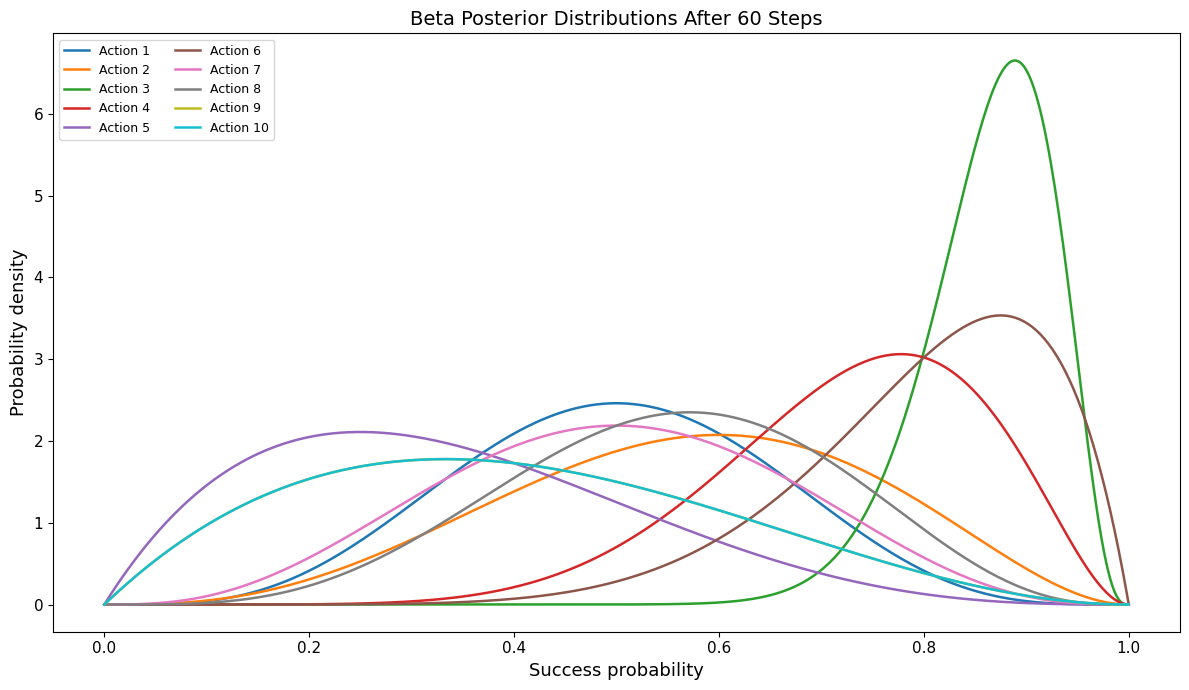

In [22]:
x = np.linspace(0, 1, 500)

plt.figure(figsize=(12, 7))

for a in range(k):
    density = beta_distribution.pdf(
        x, alpha_demo[a], beta_demo[a]
    )
    plt.plot(
        x,
        density,
        linewidth=1.8,
        label=f"Action {a + 1}"
    )

plt.xlabel("Success probability", fontsize=13)
plt.ylabel("Probability density", fontsize=13)
plt.title("Beta Posterior Distributions After 60 Steps", fontsize=14)
plt.tick_params(axis="both", labelsize=11)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## 22. Thompson Sampling Over a Longer Horizon

The 60-step experiment makes individual decisions visible. A longer experiment of

$$
1000
$$

steps is now used to examine learning over time.

The experiment records:

- received reward,
- whether the optimal action was selected,
- cumulative reward,
- cumulative percentage of optimal-action selections.

In [29]:
n_steps_ts = 1000
long_rng = np.random.default_rng(5000)

alpha_long = np.full(k, 2.0)
beta_long = np.full(k, 2.0)

rewards_ts = np.zeros(n_steps_ts)
optimal_ts = np.zeros(n_steps_ts)

for t in range(n_steps_ts):
    action, _ = select_thompson_action(
        alpha_long, beta_long, long_rng
    )

    reward = long_rng.binomial(
        1, true_probabilities[action]
    )

    update_beta_posterior(
        alpha_long, beta_long, action, reward
    )

    rewards_ts[t] = reward
    optimal_ts[t] = int(action == optimal_action_ts)

cumulative_reward = np.cumsum(rewards_ts)
cumulative_optimal_percentage = (
    np.cumsum(optimal_ts)
    / np.arange(1, n_steps_ts + 1)
    * 100
)

print(f"Total reward after {n_steps_ts} steps : {int(cumulative_reward[-1])}")
print(f"Optimal-action selections             : {int(optimal_ts.sum())}")
print(f"Optimal-action percentage             : {optimal_ts.mean() * 100:.2f}%")

Total reward after 1000 steps : 965
Optimal-action selections             : 971
Optimal-action percentage             : 97.10%


## Beta Posterior Distributions After 1000 Steps

After 1000 interactions, Thompson Sampling has collected substantially more information about the actions.

For each action, the final posterior distribution is

$$
p_a \mid \mathcal{D}
\sim
\operatorname{Beta}(\alpha_a,\beta_a).
$$

As more successes and failures are observed, the posterior distributions become more concentrated around the success probabilities supported by the collected data.

The following figure shows the Beta posterior distributions at the end of the 1000-step experiment. The dashed vertical lines indicate the true success probabilities used by the simulated environment.

In [30]:
final_posterior_means = alpha_long / (alpha_long + beta_long)
final_action_counts = (alpha_long - 2) + (beta_long - 2)

print(
    f"{'Action':<8}"
    f"{'True p':<12}"
    f"{'Alpha':<10}"
    f"{'Beta':<10}"
    f"{'Post. Mean':<15}"
    f"{'Selections':<12}"
)

print("-" * 67)

for a in range(k):
    print(
        f"{a + 1:<8}"
        f"{true_probabilities[a]:<12.3f}"
        f"{alpha_long[a]:<10.0f}"
        f"{beta_long[a]:<10.0f}"
        f"{final_posterior_means[a]:<15.3f}"
        f"{int(final_action_counts[a]):<12}"
    )

Action  True p      Alpha     Beta      Post. Mean     Selections  
-------------------------------------------------------------------
1       0.774       3         5         0.375          4           
2       0.439       2         3         0.400          1           
3       0.859       2         4         0.333          2           
4       0.697       2         3         0.400          1           
5       0.094       2         3         0.400          1           
6       0.976       953       22        0.977          971         
7       0.761       2         3         0.400          1           
8       0.786       14        5         0.737          15          
9       0.128       2         4         0.333          2           
10      0.450       3         3         0.500          2           


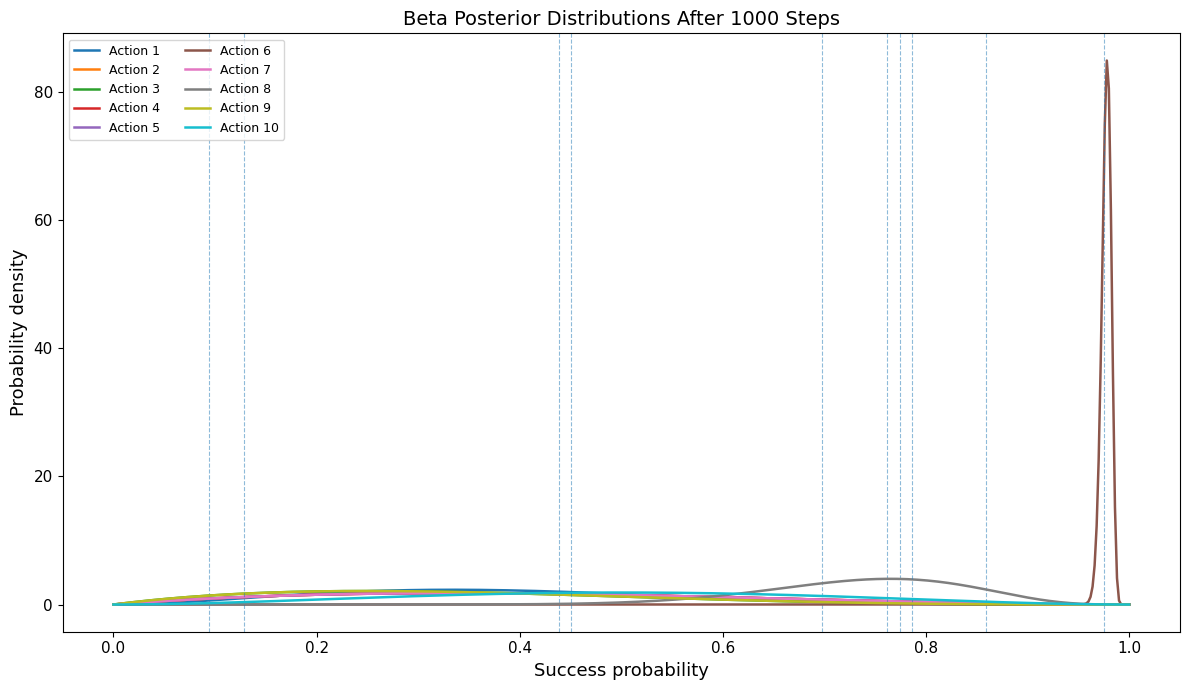

In [31]:
x = np.linspace(0, 1, 500)

plt.figure(figsize=(12, 7))

for a in range(k):
    density = beta_distribution.pdf(
        x, alpha_long[a], beta_long[a]
    )

    plt.plot(
        x,
        density,
        linewidth=1.8,
        label=f"Action {a + 1}"
    )

    plt.axvline(
        true_probabilities[a],
        linestyle="--",
        linewidth=0.8,
        alpha=0.5
    )

plt.xlabel("Success probability", fontsize=13)
plt.ylabel("Probability density", fontsize=13)
plt.title("Beta Posterior Distributions After 1000 Steps", fontsize=14)

plt.tick_params(axis="both", labelsize=11)
plt.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

### Cumulative Reward

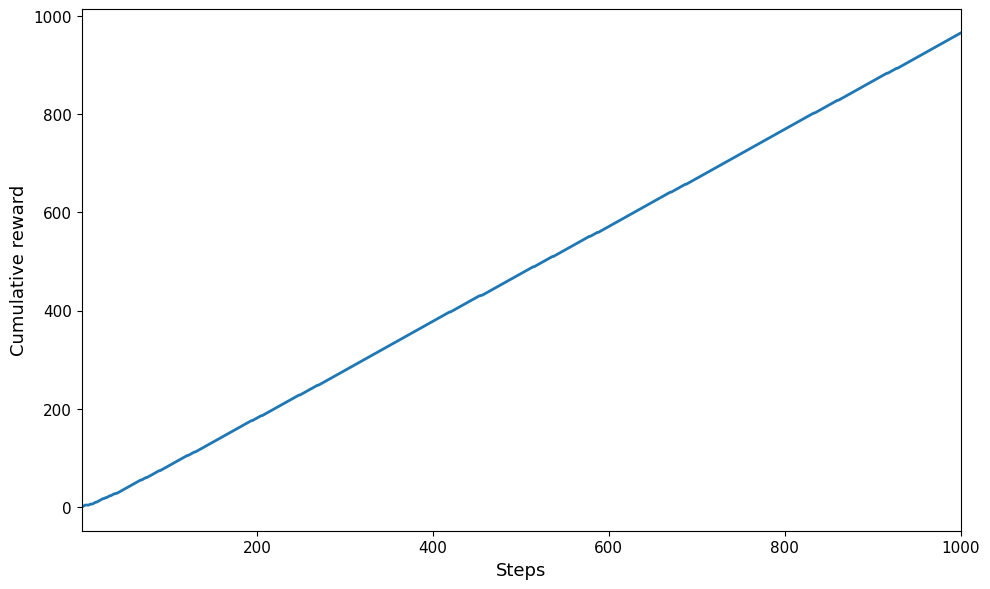

In [24]:
steps_ts = np.arange(1, n_steps_ts + 1)

plt.figure(figsize=(10, 6))
plt.plot(steps_ts, cumulative_reward, linewidth=2)
plt.xlabel("Steps", fontsize=13)
plt.ylabel("Cumulative reward", fontsize=13)
plt.xlim(1, n_steps_ts)
plt.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.show()

### Cumulative Percentage of Optimal-Action Selections

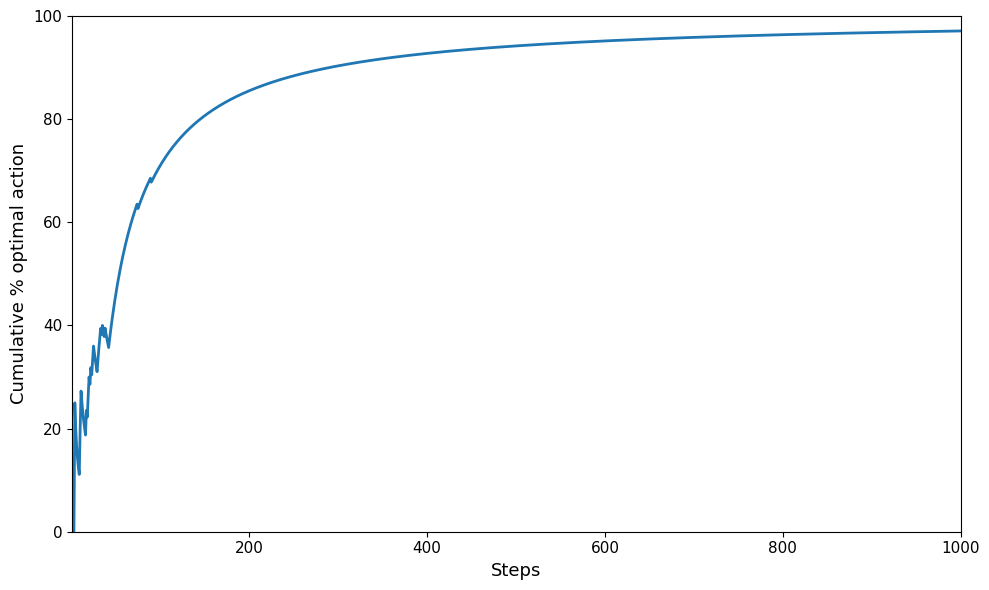

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(steps_ts, cumulative_optimal_percentage, linewidth=2)
plt.xlabel("Steps", fontsize=13)
plt.ylabel("Cumulative % optimal action", fontsize=13)
plt.xlim(1, n_steps_ts)
plt.ylim(0, 100)
plt.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.show()

# Comparison of Exploration Strategies

The methods in this notebook approach exploration differently.

### Greedy

$$
A_t=\arg\max_a Q_t(a).
$$

Greedy selection performs pure exploitation and has no deliberate exploration mechanism.

### $\epsilon$-Greedy

$$
A_t=
\begin{cases}
\text{random action}, & \text{with probability }\epsilon,\\
\arg\max_a Q_t(a), & \text{with probability }1-\epsilon.
\end{cases}
$$

Exploration is explicit but random.

### Upper Confidence Bound

$$
A_t=
\arg\max_a
\left[
Q_t(a)+c\sqrt{\frac{\ln t}{N_t(a)}}
\right].
$$

UCB directs exploration using uncertainty about the action-value estimates.

### Thompson Sampling

For the Beta-Bernoulli implementation,

$$
p_a\mid\mathcal D_t
\sim
\operatorname{Beta}(\alpha_a,\beta_a),
$$

and

$$
\tilde p_t(a)
\sim
\operatorname{Beta}(\alpha_a,\beta_a).
$$

The selected action is

$$
A_t=\arg\max_a\tilde p_t(a).
$$

Exploration emerges from posterior uncertainty rather than from a fixed random-exploration probability or an explicit confidence bonus.

# Conclusion

This notebook examined the exploration–exploitation problem using multi-armed bandits.

The Gaussian 10-armed testbed demonstrated how noisy rewards make identification of the best action difficult. Greedy action selection relies entirely on current estimates, while $\epsilon$-greedy introduces random exploration. UCB uses an uncertainty-dependent exploration bonus and directs exploration toward actions that remain insufficiently sampled.

The notebook then introduced Beta-Bernoulli Thompson Sampling using a separate 10-armed Bernoulli bandit. Beta posterior distributions represented uncertainty about the unknown success probabilities, and actions were selected using samples drawn from those distributions.

Together, these methods demonstrate several fundamental approaches for balancing the use of current knowledge with the collection of additional information.